In [52]:
import random
import matplotlib.pyplot as plt
import numpy as np
from tabulate import tabulate
from tqdm import tqdm
from scipy.stats import norm

-2.073


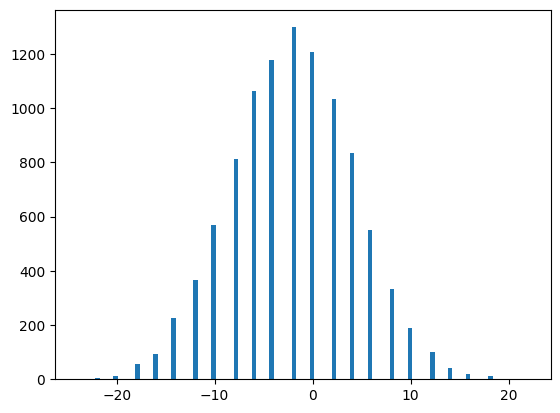

In [12]:
def bet():
    total_slots = 38
    black_slots = 18

    toss = random.random() * total_slots
    return toss < black_slots

def play_for_multiple_rounds(n: int) -> int:
    gain = 0
    for _ in range(n):
        gain += 1 if bet() else -1
    return gain

def section_1():
    random.seed(42)
    gains = []
    total_count = 10000
    for _ in range(total_count):
        gains.append(play_for_multiple_rounds(38))
    plt.hist(gains, bins = int(total_count** 0.5) + 1)
    print(np.mean(gains)) # probably -2 ?
section_1()


+------+----------+--------------------+
|  N   |   avg    |        std         |
+------+----------+--------------------+
|  10  | -0.5281  | 3.1651525065942714 |
|  25  | -1.2859  | 4.989194442993779  |
| 100  | -5.23976 | 10.016911457250682 |
| 1000 | -52.7608 | 31.466812729604502 |
+------+----------+--------------------+


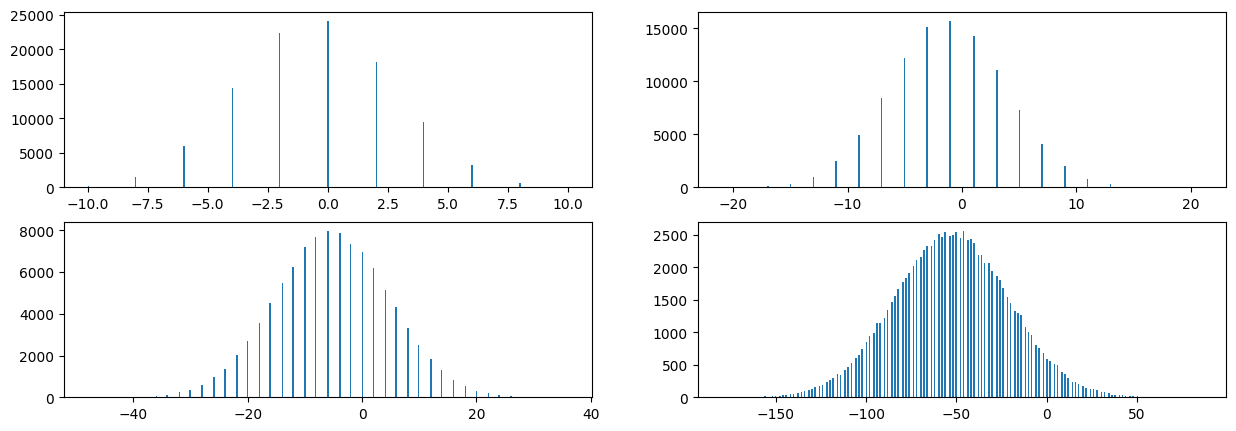

In [ ]:
def monte_carlo_sim(n: int, repeat: int = 100_000):
    gains = []
    for _ in range(repeat):
        gains.append(play_for_multiple_rounds(n))
    return gains
def section_2():
    random.seed(42)
    plt.figure(figsize=(15, 5))
    N = (10, 25, 100, 1000)
    data = [("N", "avg", "std")]
    for i, n in enumerate(N):
        gains = monte_carlo_sim(n)
        plt.subplot(2, 2, i + 1)
        plt.hist(gains, bins = int(len(gains)**0.5) + 1)
        avg = np.mean(gains)
        std = np.std(gains)
        data.append((n, avg, std))

    print(tabulate(data, headers="firstrow", floatfmt=".4f", tablefmt="pretty"))

section_2()


+------+-----------------------+---------------------+
|  N   |          avg          |         std         |
+------+-----------------------+---------------------+
|  10  | -0.05352200000000001  | 0.3154295412861643  |
|  25  | -0.053530400000000006 | 0.1993786354548551  |
| 100  |      -0.0525688       | 0.09974199349601952 |
| 1000 |      -0.05261416      | 0.03153202193793478 |
+------+-----------------------+---------------------+


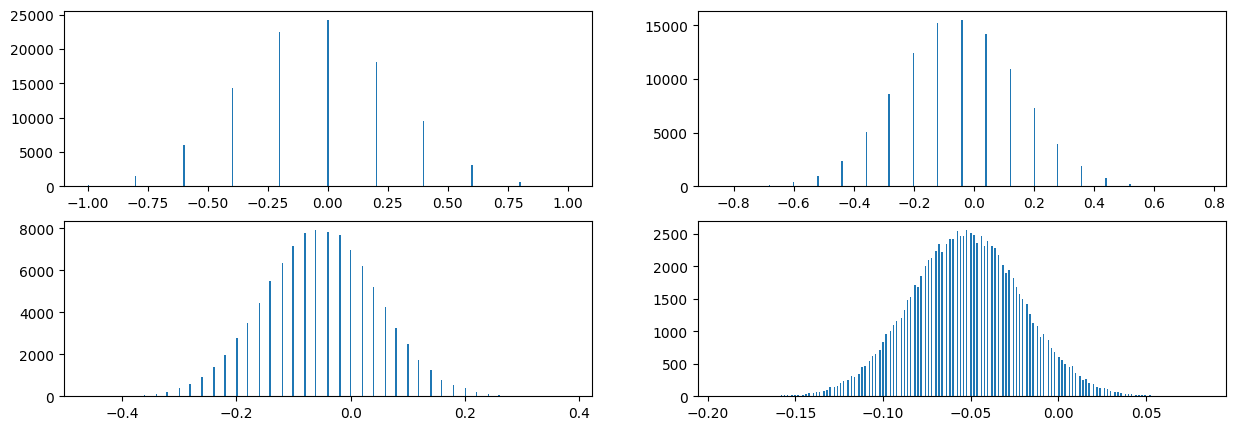

In [ ]:
def section_3():
    random.seed(42)
    plt.figure(figsize=(15, 5))
    N = (10, 25, 100, 1000)
    data = [("N", "avg", "std")]
    for i, n in enumerate(N):
        gains = np.array(monte_carlo_sim(n)) / n
        plt.subplot(2, 2, i + 1)
        plt.hist(gains, bins = int(len(gains)**0.5) + 1)
        avg = np.mean(gains)
        std = np.std(gains)
        data.append((n, avg, std))

    print(tabulate(data, headers="firstrow", floatfmt=".4f", tablefmt="pretty"))

section_3()


In [ ]:
def section_4():
    random.seed(42)
    get_mean = lambda n: -n / 19
    get_std = lambda n: (6840 * n / 6859)**0.5
    N = (10, 25, 100, 1000)
    data = [("N", "avg", "std")]
    for n in N:
        avg = get_mean(n)
        std = get_std(n)
        data.append((n, avg, std))

    print(tabulate(data, headers="firstrow", floatfmt=".4f", tablefmt="pretty"))
section_4()

+------+---------------------+--------------------+
|  N   |         avg         |        std         |
+------+---------------------+--------------------+
|  10  | -0.5263157894736842 | 3.1578947368421053 |
|  25  | -1.3157894736842106 | 4.9930699897395465 |
| 100  | -5.2631578947368425 | 9.986139979479093  |
| 1000 | -52.63157894736842  | 31.57894736842105  |
+------+---------------------+--------------------+


In [40]:
def count_loss(n: int, repeat: int ):
    lost_count = 0
    for _ in range(repeat):
        gain = play_for_multiple_rounds(n)
        if gain > 0:
            lost_count += 1
    return lost_count

def section_5():
    random.seed(42)
    total = 100_000
    lost_count = count_loss(25, total)
    print(lost_count)
    print(f"Casino loss probability is: {lost_count / total}")
section_5()


39414
Casino loss probability is: 0.39414


0.6025681132017605


100%|██████████| 326/326 [00:10<00:00, 30.21it/s]


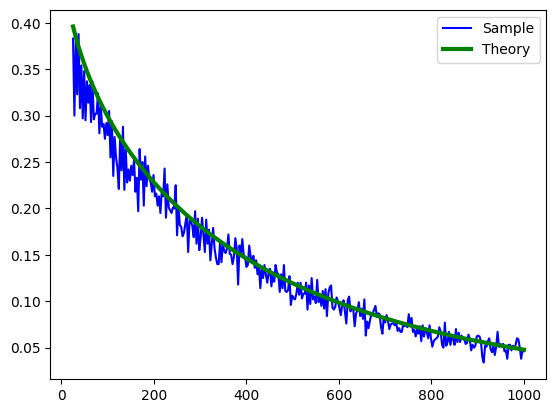

In [ ]:
def section_6():
    total = 1000
    sample_data = []
    theory_data = []
    x = []
    for n in tqdm(range(25, 1001, 3)):
        x.append(n)
        loss_count = count_loss(n = n, repeat=total)
        sample_data.append(loss_count / total)
        theory_data.append(1 - norm.cdf(0.0527 * (n** 0.5)))
    plt.plot(x, sample_data, c="blue", label="Sample")
    plt.plot(x, theory_data, c="green", lw=3, label="Theory")
    plt.legend()

section_6()